In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow
# import all necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
import random
from sklearn.metrics import confusion_matrix
import seaborn as sns
import math
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib.image import imread
import os
import shutil
from sklearn.model_selection import train_test_split
import urllib.request
from PIL import Image
import requests
from io import BytesIO
import numpy as np

In [50]:
from pathlib import Path
import os

try:
    from google.colab import drive
    RUNNING_IN_COLAB = True
except ImportError:
    drive = None
    RUNNING_IN_COLAB = False

if RUNNING_IN_COLAB:
    drive.mount('/content/drive')

DEFAULT_DATA_ROOT = Path('/content/drive/MyDrive/Colab_Notebooks/Data')
DATA_ROOT = Path(os.environ.get('VISION_AI_DATA_ROOT', DEFAULT_DATA_ROOT))
GROUND_TRUTH_CSV = Path(os.environ.get('VISION_AI_GROUND_TRUTH_CSV', DATA_ROOT / 'ISIC_2020_Training_GroundTruth_v2.csv'))
DEFAULT_LOCAL_WORK_ROOT = Path('/content/vision_ai_local') if RUNNING_IN_COLAB else Path.cwd() / '.vision_ai_local'
LOCAL_WORK_ROOT = Path(os.environ.get('VISION_AI_LOCAL_WORK_ROOT', DEFAULT_LOCAL_WORK_ROOT))
LOCAL_STAGE_DIR = LOCAL_WORK_ROOT / 'staged_datasets'
LOCAL_TRAIN_DATASET_DIR = LOCAL_STAGE_DIR / 'train'
LOCAL_TEST_DATASET_DIR = LOCAL_STAGE_DIR / 'test'
ARTIFACTS_DIR = Path(os.environ.get('VISION_AI_ARTIFACTS_DIR', DATA_ROOT / 'cgan_artifacts'))
CHECKPOINT_DIR = ARTIFACTS_DIR / 'checkpoints'
SAMPLE_DIR = ARTIFACTS_DIR / 'generated_samples'
HISTORY_DIR = ARTIFACTS_DIR / 'history'
CHECKPOINT_EVERY_N_EPOCHS = int(os.environ.get('VISION_AI_CHECKPOINT_EVERY_N_EPOCHS', 100))
SAMPLES_EVERY_N_EPOCHS = int(os.environ.get('VISION_AI_SAMPLES_EVERY_N_EPOCHS', 100))

for path in [ARTIFACTS_DIR, CHECKPOINT_DIR, SAMPLE_DIR, HISTORY_DIR, LOCAL_STAGE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f'Running in Colab: {RUNNING_IN_COLAB}')
print(f'Ground truth CSV: {GROUND_TRUTH_CSV}')
print(f'Local staging directory: {LOCAL_STAGE_DIR}')
print(f'Artifacts directory: {ARTIFACTS_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab: True
Ground truth CSV: /content/drive/MyDrive/Colab_Notebooks/Data/ISIC_2020_Training_GroundTruth_v2.csv
Local staging directory: /content/vision_ai_local/staged_datasets
Artifacts directory: /content/drive/MyDrive/Colab_Notebooks/Data/cgan_artifacts


In [9]:
from pathlib import Path

In [24]:
VALID_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def _count_images_in_directory(directory):
    directory = Path(directory)
    return sum(1 for path in directory.iterdir() if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS)

In [26]:
def validate_class_folders(dataset_dir, class_names=None):
    dataset_dir = Path(dataset_dir)
    if not dataset_dir.exists():
        raise FileNotFoundError(f'Dataset directory does not exist: {dataset_dir}')

    if class_names is None:
        class_names = sorted(path.name for path in dataset_dir.iterdir() if path.is_dir())

    counts = {}
    for class_name in class_names:
        class_dir = dataset_dir / class_name
        if not class_dir.exists() or not class_dir.is_dir():
            raise FileNotFoundError(f'Missing class folder: {class_dir}')
        counts[class_name] = _count_images_in_directory(class_dir)
        if counts[class_name] == 0:
            raise ValueError(f'Class folder is empty: {class_dir}')

    return counts

In [40]:
def stage_dataset_to_local(source_dataset_dir, local_dataset_dir, class_names=None):
    source_dataset_dir = Path(source_dataset_dir)
    local_dataset_dir = Path(local_dataset_dir)
    source_counts = validate_class_folders(source_dataset_dir, class_names)
    class_names = list(source_counts.keys())

    if local_dataset_dir.exists():
        try:
            local_counts = validate_class_folders(local_dataset_dir, class_names)
        except (FileNotFoundError, ValueError):
            local_counts = None

        if local_counts == source_counts:
            print(f'Local stage is up to date at {local_dataset_dir}')
            print(f'Local class counts: {local_counts}')
            return local_counts

        shutil.rmtree(local_dataset_dir)

    local_dataset_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(source_dataset_dir, local_dataset_dir)
    local_counts = validate_class_folders(local_dataset_dir, class_names)

    if local_counts != source_counts:
        raise RuntimeError(
            f'Local staging validation failed for {local_dataset_dir}. '
            f'Expected {source_counts}, found {local_counts}.'
        )

    print(f'Staged dataset to local disk: {local_dataset_dir}')
    print(f'Local class counts: {local_counts}')
    return local_counts

def collect_labeled_file_paths(dataset_dir, class_to_index):
    dataset_dir = Path(dataset_dir)
    file_paths = []
    labels = []

    for class_name, class_index in class_to_index.items():
        class_dir = dataset_dir / class_name
        class_files = sorted(
            str(path) for path in class_dir.iterdir()
            if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS
        )
        file_paths.extend(class_files)
        labels.extend([class_index] * len(class_files))

    if not file_paths:
        raise ValueError(f'No image files found in staged dataset: {dataset_dir}')

    return file_paths, np.asarray(labels, dtype=np.int32)

In [33]:
train_data_set = "/content/drive/MyDrive/Colab_Notebooks/Data/Image_Train"
train_dataset_counts = validate_class_folders(train_data_set)
print(f'Training dataset validated: {train_dataset_counts}')

Training dataset validated: {'benign': 400, 'malignant': 584}


In [35]:
test_data_set = "/content/drive/MyDrive/Colab_Notebooks/Data/Cancer_test/organized_data"
test_dataset_counts = validate_class_folders(test_data_set)
print(f'Testing dataset validated: {test_dataset_counts}')

Testing dataset validated: {'benign': 100, 'malignant': 60}


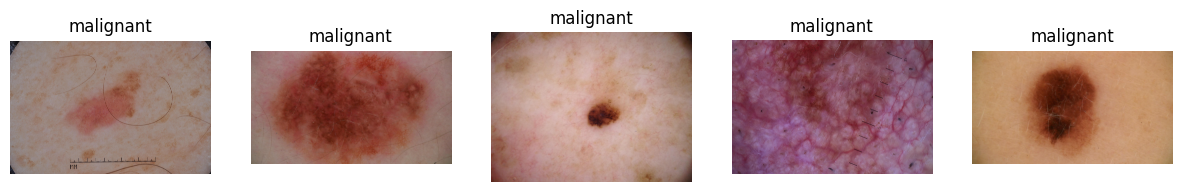

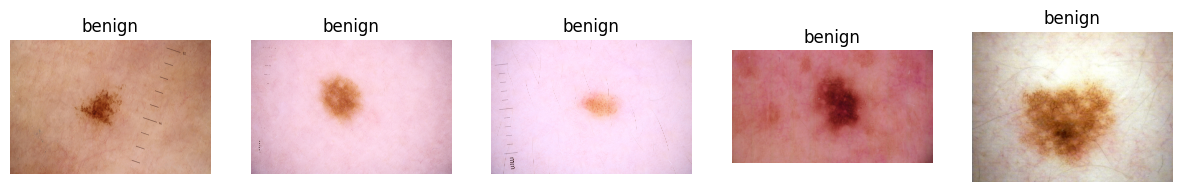

In [36]:
#function to display image from our dataset
def display_sample_images(class_name, dataset_path):
    folder_path = os.path.join(dataset_path, class_name)
    images = random.sample(os.listdir(folder_path), 5)
    plt.figure(figsize=(15, 5))
    for idx, img_name in enumerate(images):
        img = imread(os.path.join(folder_path, img_name))
        plt.subplot(1, 5, idx+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

display_sample_images('malignant',train_data_set)
display_sample_images('benign',train_data_set)

In [37]:
img_height, img_width = 128, 128
IMG_SHAPE = (img_height, img_width, 3)
NOISE_DIM = 100
batch_size = 32
selected_batch_size = batch_size
CANDIDATE_BATCH_SIZES = [32, 64, 128]
RUN_BATCH_SIZE_BENCHMARK = False
BENCHMARK_MODE = False
BENCHMARK_EPOCHS = 3
BENCHMARK_STEPS = 16
USE_XLA = False
ENABLE_MIXED_PRECISION = False  # Disabled to prevent CUDA_ERROR_INVALID_HANDLE bug
NUM_CLASSES = 2
EPOCHS = 1100
D_LR = 2e-4  # Increased learning rate for Discriminator to reduce its loss
G_LR = 2e-4  # Standard learning rate for Generator
BETA_1 = 0.5


In [38]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
from types import SimpleNamespace

AUTOTUNE = tf.data.AUTOTUNE
PHYSICAL_DEVICES = tf.config.list_physical_devices()
GPU_DEVICES = tf.config.list_physical_devices('GPU')
LOGICAL_GPU_DEVICES = tf.config.list_logical_devices('GPU')
GPU_AVAILABLE = bool(GPU_DEVICES)

if GPU_AVAILABLE and ENABLE_MIXED_PRECISION:
    mixed_precision.set_global_policy('mixed_float16')
else:
    mixed_precision.set_global_policy('float32')

MIXED_PRECISION_ENABLED = mixed_precision.global_policy().name == 'mixed_float16'

print(f'TensorFlow physical devices: {PHYSICAL_DEVICES}')
print(f'TensorFlow GPU devices: {GPU_DEVICES}')
print(f'TensorFlow logical GPU devices: {LOGICAL_GPU_DEVICES}')
print(f'GPU available: {GPU_AVAILABLE}')
print(f'Mixed precision enabled: {MIXED_PRECISION_ENABLED}')
print(f'Configured batch size: {selected_batch_size}')
print(f'Candidate batch sizes: {CANDIDATE_BATCH_SIZES}')
print(f'Benchmark mode: {BENCHMARK_MODE}')
print(f'XLA requested: {USE_XLA}')

def load_and_preprocess_image(file_path, label):
    image_bytes = tf.io.read_file(file_path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [img_height, img_width], antialias=True)
    image = tf.cast(image, tf.float32) / 255.0
    return image, tf.cast(label, tf.int32)

def build_tf_image_dataset(file_paths, labels, batch_size, shuffle):
    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.cache()
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(file_paths), reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

def build_dataset_runtime(file_paths, labels, class_indices, staged_dir, batch_size, shuffle):
    num_samples = len(file_paths)
    steps_per_epoch = math.ceil(num_samples / batch_size)
    dataset = build_tf_image_dataset(file_paths, labels, batch_size=batch_size, shuffle=shuffle)
    generator_like = SimpleNamespace(
        class_indices=class_indices.copy(),
        samples=num_samples,
        batch_size=batch_size,
        staged_dir=staged_dir,
    )
    return dataset, generator_like, num_samples, steps_per_epoch

def build_runtime_state(train_file_paths, train_labels, test_file_paths, test_labels,
                        class_to_index, staged_train_dir, staged_test_dir, batch_size):
    train_dataset, train_generator, train_num_samples, train_steps_per_epoch = build_dataset_runtime(
        train_file_paths, train_labels, class_to_index, staged_train_dir, batch_size, shuffle=True
    )
    test_dataset, test_generator, test_num_samples, test_steps = build_dataset_runtime(
        test_file_paths, test_labels, class_to_index, staged_test_dir, batch_size, shuffle=False
    )
    return {
        'batch_size': batch_size,
        'train_dataset': train_dataset,
        'test_dataset': test_dataset,
        'train_generator': train_generator,
        'test_generator': test_generator,
        'train_num_samples': train_num_samples,
        'test_num_samples': test_num_samples,
        'train_steps_per_epoch': train_steps_per_epoch,
        'test_steps': test_steps,
    }

TensorFlow physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow logical GPU devices: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
GPU available: True
Mixed precision enabled: False
Configured batch size: 32
Candidate batch sizes: [32, 64, 128]
Benchmark mode: False
XLA requested: False


In [41]:
staged_train_data_set = train_data_set
staged_test_data_set = test_data_set
staged_train_counts = stage_dataset_to_local(train_data_set, staged_train_data_set, list(train_dataset_counts.keys()))
staged_test_counts = stage_dataset_to_local(test_data_set, staged_test_data_set, list(test_dataset_counts.keys()))

Local stage is up to date at /content/drive/MyDrive/Colab_Notebooks/Data/Image_Train
Local class counts: {'benign': 400, 'malignant': 584}
Local stage is up to date at /content/drive/MyDrive/Colab_Notebooks/Data/Cancer_test/organized_data
Local class counts: {'benign': 100, 'malignant': 60}


In [42]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
import glob
import os
from pathlib import Path

malignant_dir = Path(staged_train_data_set) / 'malignant'
benign_dir = Path(staged_train_data_set) / 'benign'

# Clean up any previously generated SMOTE or augmented images
for old_aug_img in glob.glob(str(malignant_dir / '*smote*.jpg')) + glob.glob(str(malignant_dir / '*aug*.jpg')):
    os.remove(old_aug_img)

# 1. Load original images into memory
def load_original_images(directory):
    images = []
    for img_path in glob.glob(str(directory / '*.jpg')):
        filename = os.path.basename(img_path)
        if 'aug' not in filename and 'smote' not in filename:
            img = load_img(img_path, target_size=(128, 128))
            x = img_to_array(img)
            images.append(x)
    return np.array(images)

print("Loading original images for Augmentation...")
benign_images = load_original_images(benign_dir)
malignant_images = load_original_images(malignant_dir)

num_benign = len(benign_images)
num_malignant = len(malignant_images)
print(f"Original shapes: Benign={benign_images.shape}, Malignant={malignant_images.shape}")
print(f"Malignant count: {num_malignant}, Benign count: {num_benign}")

if num_malignant > 0 and num_malignant < num_benign:
    num_to_generate = num_benign - num_malignant
    print(f"Applying Image Augmentation to generate {num_to_generate} images. This might take a minute...")

    datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='reflect'
    )

    # Flow generates batches of randomly transformed images and saves them to disk
    aug_gen = datagen.flow(
        malignant_images,
        batch_size=32,
        save_to_dir=str(malignant_dir),
        save_prefix='aug',
        save_format='jpg'
    )

    generated_count = 0
    for _ in aug_gen:
        generated_count += 32
        if generated_count >= num_to_generate:
            break

    # Re-validate to update the staging counts
    staged_train_counts = validate_class_folders(staged_train_data_set)
    print(f"Augmentation complete. New class counts: {staged_train_counts}")
else:
    print("No augmentation needed. Classes are balanced.")


Loading original images for Augmentation...
Original shapes: Benign=(400, 128, 128, 3), Malignant=(584, 128, 128, 3)
Malignant count: 584, Benign count: 400
No augmentation needed. Classes are balanced.


In [43]:
CLASS_TO_INDEX = {
    class_name: class_index
    for class_index, class_name in enumerate(sorted(staged_train_counts))
}
INDEX_TO_CLASS = {index: label for label, index in CLASS_TO_INDEX.items()}
print(f'train_generator.class_indices: {CLASS_TO_INDEX}')

train_file_paths, train_labels = collect_labeled_file_paths(staged_train_data_set, CLASS_TO_INDEX)
print(f'Staged training samples: {len(train_file_paths)}')

train_generator.class_indices: {'benign': 0, 'malignant': 1}
Staged training samples: 984


In [44]:
test_class_indices = {
    class_name: class_index
    for class_index, class_name in enumerate(sorted(staged_test_counts))
}
print(f'test_generator.class_indices: {test_class_indices}')
if test_class_indices != CLASS_TO_INDEX:
    raise ValueError(
        f'Train/test class index mappings do not match: {CLASS_TO_INDEX} vs {test_class_indices}'
    )

test_file_paths, test_labels = collect_labeled_file_paths(staged_test_data_set, CLASS_TO_INDEX)
runtime_state = build_runtime_state(
    train_file_paths,
    train_labels,
    test_file_paths,
    test_labels,
    CLASS_TO_INDEX,
    staged_train_data_set,
    staged_test_data_set,
    selected_batch_size,
)
train_dataset = runtime_state['train_dataset']
test_dataset = runtime_state['test_dataset']
train_generator = runtime_state['train_generator']
test_generator = runtime_state['test_generator']
train_num_samples = runtime_state['train_num_samples']
test_num_samples = runtime_state['test_num_samples']
train_steps_per_epoch = runtime_state['train_steps_per_epoch']
test_steps = runtime_state['test_steps']

print(f'Staged test samples: {test_num_samples}')
print(f'Active batch size: {selected_batch_size}')
print(f'Training steps per epoch: {train_steps_per_epoch}')
print(f'Test steps: {test_steps}')

test_generator.class_indices: {'benign': 0, 'malignant': 1}
Staged test samples: 160
Active batch size: 32
Training steps per epoch: 31
Test steps: 5


In [45]:
def build_generator(noise_dim, num_classes, img_shape):
    # Latent vector input
    noise_input = Input(shape=(noise_dim,), name='noise_input')

    # Label input - Use float32 to avoid int32 casting bugs on GPU with mixed precision
    label_input = Input(shape=(1,), name='label_input', dtype=tf.float32)

    # Workaround: Avoid tf.cast and tf.one_hot entirely.
    # For binary classification (0 or 1), we can compute one-hot mathematically.
    if num_classes == 2:
        encoded_label = layers.concatenate([1.0 - label_input, label_input], axis=-1)
    else:
        # Fallback for >2 classes (might still be risky with the TF bug)
        encoded_label = layers.Lambda(lambda x: tf.cast(tf.one_hot(tf.cast(x[:, 0], tf.int32), num_classes), tf.float32))(label_input)

    label_embedding = layers.Dense(50, use_bias=False, dtype='float32')(encoded_label)

    # Concatenate noise and label embeddings instead of multiplying to preserve the signal
    merged_input = layers.concatenate([noise_input, label_embedding])

    # First dense layer to upsample merged input
    x = layers.Dense(4 * 4 * 512, use_bias=False)(merged_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Reshape to appropriate dimensions before Conv2DTranspose
    x = layers.Reshape((4, 4, 512))(x)

    # Upsampling layers
    x = layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 4x4 -> 8x8
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 8x8 -> 16x16
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 16x16 -> 32x32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False)(x) # 32x32 -> 64x64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    # Final Conv2DTranspose to reach exactly 128x128
    # IMPORTANT: use_bias=True allows the generator to shift the baseline color away from 0 (gray)
    x = layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=True, activation='tanh')(x) # 64x64 -> 128x128

    generator = Model([noise_input, label_input], x, name='generator')
    return generator

# Build the generator
generator = build_generator(NOISE_DIM, NUM_CLASSES, IMG_SHAPE)
generator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 1)         │          0 │ label_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ subtract[0][0],   │
│ (Concatenate)       │                   │            │ label_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50)        │        100 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 150)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8192)      │  1,228,800 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8192)      │     32,768 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 8192)      │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 512) │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  3,276,800 │ reshape[0][0]     │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    819,200 │ leaky_re_lu_1[0]… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    204,800 │ leaky_re_lu_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                 

 Total params: 5,617,991 (21.43 MB)

 Trainable params: 5,600,647 (21.36 MB)

 Non-trainable params: 17,344 (67.75 KB)

Next, we will define the Discriminator model. This model will take an image and a class label and predict whether the image is real or fake.

In [46]:
def build_discriminator(num_classes, img_shape):
    # Image input
    image_input = Input(shape=img_shape, name='image_input')

    # Label input
    label_input = Input(shape=(1,), name='label_input')
    label_embedding = layers.Embedding(num_classes, img_shape[0] * img_shape[1])(label_input) # Embed label to image size
    label_embedding = layers.Reshape((img_shape[0], img_shape[1], 1))(label_embedding) # Reshape to concatenate with image

    # Concatenate image and label embedding
    merged_input = layers.concatenate([image_input, label_embedding], axis=-1) # Concatenate along the channel axis

    # Downsampling layers - Made deeper to match the generator's complexity
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding='same')(merged_input)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(512, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # Flatten and output
    x = layers.Flatten()(x)
    output = layers.Dense(1, activation='sigmoid')(x) # Binary classification (real/fake)

    discriminator = Model([image_input, label_input], output, name='discriminator')
    return discriminator

# Build the discriminator
discriminator = build_discriminator(NUM_CLASSES, IMG_SHAPE)
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 16384)  │     32,768 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 128,  │          0 │ embedding[0][0]   │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ image_input[0][0… │
│ (Concatenate)       │ 4)                │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      4,160 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ leaky_re_lu_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │    131,200 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ leaky_re_lu_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │    524,544 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_7[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 8, 512) │  2,097,664 │ dropout_2[0][0] 

 Total params: 2,826,689 (10.78 MB)

 Trainable params: 2,824,897 (10.78 MB)

 Non-trainable params: 1,792 (7.00 KB)

Now we will compile both the discriminator and the combined CGAN model. The discriminator is trained to distinguish between real and fake images, while the generator is trained through the combined model to fool the discriminator.

In [47]:
def make_optimizer(learning_rate, beta_1):
    optimizer = Adam(learning_rate=learning_rate, beta_1=beta_1)
    if MIXED_PRECISION_ENABLED:
        optimizer = mixed_precision.LossScaleOptimizer(optimizer)
    return optimizer

def reset_training_optimizers():
    global discriminator_optimizer, generator_optimizer
    discriminator_optimizer = make_optimizer(D_LR, BETA_1)
    generator_optimizer = make_optimizer(G_LR, BETA_1)
    discriminator.trainable = True
    discriminator.compile(optimizer=discriminator_optimizer, loss='binary_crossentropy')
    discriminator.trainable = False
    cgan_model.compile(optimizer=generator_optimizer, loss='binary_crossentropy')
    discriminator.trainable = True

# Compile the discriminator with the lower D_LR
discriminator_optimizer = make_optimizer(D_LR, BETA_1)
discriminator.compile(optimizer=discriminator_optimizer,
                      loss='binary_crossentropy')

# Build the combined GAN model
discriminator.trainable = False # Discriminator weights are frozen during generator training

noise_input = Input(shape=(NOISE_DIM,), name='noise_input_gan')
label_input = Input(shape=(1,), name='label_input_gan')

fake_image = generator([noise_input, label_input])

discriminator_output = discriminator([fake_image, label_input])

# Compile the CGAN model with the standard G_LR
cgan_model = Model([noise_input, label_input], discriminator_output, name='cgan_model')
generator_optimizer = make_optimizer(G_LR, BETA_1)
cgan_model.compile(optimizer=generator_optimizer,
                   loss='binary_crossentropy')

reset_training_optimizers()

cgan_model.summary()

Model: "cgan_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ noise_input_gan     │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input_gan     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generator           │ (None, 128, 128,  │  5,617,991 │ noise_input_gan[… │
│ (Functional)        │ 3)                │            │ label_input_gan[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ discriminator       │ (None, 1)         │  2,826,689 │ generator[0][0],  │
│ (Functional)        │                   │            │ label_input_gan[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,444,680 (32.21 MB)

 Trainable params: 8,425,544 (32.14 MB)

 Non-trainable params: 19,136 (74.75 KB)

In [51]:
import gc
import json
import time

def save_training_history(history, history_dir):
    history_dir = Path(history_dir)
    history_dir.mkdir(parents=True, exist_ok=True)
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_dir / 'training_history.csv', index=False)
    with open(history_dir / 'training_history.json', 'w') as history_file:
        json.dump(history, history_file, indent=2)

def save_batch_benchmark_results(results, history_dir):
    if not results:
        return
    history_dir = Path(history_dir)
    history_dir.mkdir(parents=True, exist_ok=True)
    benchmark_df = pd.DataFrame(results)
    benchmark_df.to_csv(history_dir / 'batch_size_benchmark.csv', index=False)
    with open(history_dir / 'batch_size_benchmark.json', 'w') as benchmark_file:
        json.dump(results, benchmark_file, indent=2)

def save_model_checkpoint(generator, discriminator, checkpoint_dir, epoch):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    epoch_dir = checkpoint_dir / f'epoch_{epoch + 1:04d}'
    epoch_dir.mkdir(parents=True, exist_ok=True)
    generator.save_weights(str(epoch_dir / 'generator.weights.h5'))
    discriminator.save_weights(str(epoch_dir / 'discriminator.weights.h5'))
    print(f'  Saved checkpoint to {epoch_dir}')

def save_generated_image_grid(generator, noise_dim, class_to_index, sample_dir, epoch, num_samples=4):
    sample_dir = Path(sample_dir)
    sample_dir.mkdir(parents=True, exist_ok=True)
    class_names = list(class_to_index.keys())
    noise = tf.random.normal((len(class_names) * num_samples, noise_dim))
    labels = []
    for class_name in class_names:
        labels.extend([class_to_index[class_name]] * num_samples)
    labels = tf.convert_to_tensor(np.asarray(labels, dtype=np.int32).reshape(-1, 1))
    generated_images = generator([noise, labels], training=False).numpy().astype(np.float32)
    generated_images = np.clip((generated_images + 1) / 2.0, 0.0, 1.0)

    fig, axes = plt.subplots(len(class_names), num_samples, figsize=(num_samples * 3, len(class_names) * 3))
    axes = np.atleast_2d(axes)
    image_index = 0
    for row_index, class_name in enumerate(class_names):
        for col_index in range(num_samples):
            axes[row_index, col_index].imshow(generated_images[image_index], vmin=0, vmax=1)
            axes[row_index, col_index].set_title(class_name)
            axes[row_index, col_index].axis('off')
            image_index += 1
    fig.suptitle(f'Generated Samples After Epoch {epoch + 1}', fontsize=16)
    fig.tight_layout()
    output_path = sample_dir / f'epoch_{epoch + 1:04d}.png'
    fig.savefig(output_path, bbox_inches='tight')
    plt.close(fig)
    print(f'  Saved generated image grid to {output_path}')

def format_duration(seconds):
    seconds = max(0, int(seconds))
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    if hours:
        return f'{hours:02d}:{minutes:02d}:{seconds:02d}'
    return f'{minutes:02d}:{seconds:02d}'

def get_eager_batch_size(images):
    if images.shape[0] is not None:
        return int(images.shape[0])
    return int(tf.shape(images)[0].numpy())

def scale_loss_for_optimizer(optimizer, loss):
    if hasattr(optimizer, 'scale_loss'):
        return optimizer.scale_loss(loss)
    return loss

def apply_gradients_safely(optimizer, gradients, variables):
    gradients_and_variables = [
        (gradient, variable)
        for gradient, variable in zip(gradients, variables)
        if gradient is not None
    ]
    optimizer.apply_gradients(gradients_and_variables)

discriminator.trainable = True
discriminator_loss_fn = tf.keras.losses.BinaryCrossentropy()
generator_loss_fn = tf.keras.losses.BinaryCrossentropy()

def build_train_step(jit_compile=False):
    @tf.function(reduce_retracing=True, jit_compile=jit_compile)
    def _train_step(real_images, real_labels):
        real_labels = tf.cast(tf.reshape(real_labels, (-1, 1)), tf.int32)
        real_images_scaled = tf.cast((real_images * 2.0) - 1.0, tf.float32)
        current_batch_size = tf.shape(real_images_scaled)[0]

        noise_for_discriminator = tf.random.normal((current_batch_size, NOISE_DIM))
        fake_labels = tf.random.uniform((current_batch_size, 1), minval=0, maxval=NUM_CLASSES, dtype=tf.int32)
        real_target_labels = tf.ones((current_batch_size, 1), dtype=tf.float32) * 0.9
        fake_target_labels = tf.zeros((current_batch_size, 1), dtype=tf.float32)

        with tf.GradientTape() as discriminator_tape:
            fake_images = generator([noise_for_discriminator, fake_labels], training=False)

            # FIX: Concatenate real and fake images into a single batch to share Batch Normalization statistics
            combined_images = tf.concat([real_images_scaled, fake_images], axis=0)
            combined_labels = tf.concat([real_labels, fake_labels], axis=0)

            combined_predictions = discriminator([combined_images, combined_labels], training=True)

            # Split predictions back into real and fake
            real_predictions, fake_predictions = tf.split(combined_predictions, num_or_size_splits=2, axis=0)

            real_predictions_float32 = tf.cast(real_predictions, tf.float32)
            fake_predictions_float32 = tf.cast(fake_predictions, tf.float32)

            d_loss_real = discriminator_loss_fn(real_target_labels, real_predictions_float32)
            d_loss_fake = discriminator_loss_fn(fake_target_labels, fake_predictions_float32)
            discriminator_loss = d_loss_real + d_loss_fake
            scaled_discriminator_loss = scale_loss_for_optimizer(discriminator_optimizer, discriminator_loss)

        discriminator_gradients = discriminator_tape.gradient(scaled_discriminator_loss, discriminator.trainable_variables)
        apply_gradients_safely(discriminator_optimizer, discriminator_gradients, discriminator.trainable_variables)

        noise_for_generator = tf.random.normal((current_batch_size, NOISE_DIM))
        generator_labels = tf.random.uniform((current_batch_size, 1), minval=0, maxval=NUM_CLASSES, dtype=tf.int32)
        generator_target_labels = tf.ones((current_batch_size, 1), dtype=tf.float32)

        with tf.GradientTape() as generator_tape:
            generated_images = generator([noise_for_generator, generator_labels], training=True)
            generator_predictions = discriminator([generated_images, generator_labels], training=False)
            generator_predictions_float32 = tf.cast(generator_predictions, tf.float32)
            g_loss = generator_loss_fn(generator_target_labels, generator_predictions_float32)
            scaled_generator_loss = scale_loss_for_optimizer(generator_optimizer, g_loss)

        generator_gradients = generator_tape.gradient(scaled_generator_loss, generator.trainable_variables)
        apply_gradients_safely(generator_optimizer, generator_gradients, generator.trainable_variables)

        return (
            tf.cast(d_loss_real, tf.float32),
            tf.cast(d_loss_fake, tf.float32),
            tf.cast(g_loss, tf.float32),
            tf.reduce_mean(real_predictions_float32),
            tf.reduce_mean(fake_predictions_float32),
        )

    return _train_step

def run_train_step_with_fallback(train_step_fn, real_images, real_labels, xla_active):
    try:
        return train_step_fn(real_images, real_labels), train_step_fn, xla_active
    except tf.errors.ResourceExhaustedError:
        raise
    except Exception as exc:
        if xla_active:
            print(f'  XLA train_step failed ({type(exc).__name__}: {exc}). Falling back to non-XLA.')
            fallback_train_step = build_train_step(jit_compile=False)
            return fallback_train_step(real_images, real_labels), fallback_train_step, False
        raise

def benchmark_batch_sizes(candidate_batch_sizes, benchmark_epochs=3, benchmark_steps=16, use_xla=False):
    benchmark_results = []
    base_generator_weights = generator.get_weights()
    base_discriminator_weights = discriminator.get_weights()

    for candidate_batch_size in candidate_batch_sizes:
        print(f'\nBenchmarking batch size {candidate_batch_size}...')
        runtime = None
        images_processed = 0
        epoch_times = []

        try:
            generator.set_weights(base_generator_weights)
            discriminator.set_weights(base_discriminator_weights)
            reset_training_optimizers()

            runtime = build_runtime_state(
                train_file_paths,
                train_labels,
                test_file_paths,
                test_labels,
                CLASS_TO_INDEX,
                staged_train_data_set,
                staged_test_data_set,
                candidate_batch_size,
            )

            candidate_train_step = build_train_step(jit_compile=use_xla)
            xla_active = use_xla

            for _ in range(benchmark_epochs):
                epoch_start = time.perf_counter()
                step_count = 0
                for real_images, real_labels in runtime['train_dataset']:
                    if benchmark_steps and step_count >= benchmark_steps:
                        break
                    (_, _, _, _, _), candidate_train_step, xla_active = run_train_step_with_fallback(
                        candidate_train_step, real_images, real_labels, xla_active
                    )
                    images_processed += get_eager_batch_size(real_images)
                    step_count += 1
                epoch_times.append(time.perf_counter() - epoch_start)

            total_time = float(np.sum(epoch_times))
            seconds_per_epoch = float(np.mean(epoch_times))
            images_per_second = images_processed / total_time if total_time > 0 else float('inf')
            steps_tested = min(runtime['train_steps_per_epoch'], benchmark_steps) if benchmark_steps else runtime['train_steps_per_epoch']

            result = {
                'batch_size': int(candidate_batch_size),
                'status': 'ok',
                'seconds_per_epoch': float(seconds_per_epoch),
                'images_per_second': float(images_per_second),
                'steps_tested_per_epoch': int(steps_tested),
                'mixed_precision': bool(MIXED_PRECISION_ENABLED),
                'xla_used': bool(xla_active),
            }
            benchmark_results.append(result)

            print(
                f'  Batch size {candidate_batch_size}: {seconds_per_epoch:.2f}s/epoch | '
                f'{images_per_second:.2f} images/s | mixed_precision={MIXED_PRECISION_ENABLED} | '
                f'xla_used={xla_active}'
            )

        except tf.errors.ResourceExhaustedError:
            benchmark_results.append({
                'batch_size': int(candidate_batch_size),
                'status': 'oom',
                'seconds_per_epoch': None,
                'images_per_second': None,
                'steps_tested_per_epoch': None,
                'mixed_precision': bool(MIXED_PRECISION_ENABLED),
                'xla_used': bool(use_xla),
            })
            print(f'  Batch size {candidate_batch_size}: OOM, skipping.')
        except Exception as exc:
            benchmark_results.append({
                'batch_size': int(candidate_batch_size),
                'status': f'failed: {type(exc).__name__}',
                'seconds_per_epoch': None,
                'images_per_second': None,
                'steps_tested_per_epoch': None,
                'mixed_precision': bool(MIXED_PRECISION_ENABLED),
                'xla_used': bool(use_xla),
            })
            print(f'  Batch size {candidate_batch_size}: failed with {type(exc).__name__}: {exc}')
        finally:
            if runtime is not None:
                del runtime
            gc.collect()
            generator.set_weights(base_generator_weights)
            discriminator.set_weights(base_discriminator_weights)
            reset_training_optimizers()

    save_batch_benchmark_results(benchmark_results, HISTORY_DIR)

    stable_results = [result for result in benchmark_results if result['status'] == 'ok']
    recommended_batch_size = max(
        stable_results,
        key=lambda result: result['images_per_second']
    )['batch_size'] if stable_results else selected_batch_size

    print(f'Recommended batch size: {recommended_batch_size}')
    return benchmark_results, recommended_batch_size

def train_cgan(generator, discriminator, cgan_model, train_dataset, train_num_samples, train_steps_per_epoch,
               noise_dim, epochs, batch_size, num_classes, class_to_index, checkpoint_dir, sample_dir, history_dir,
               checkpoint_every=100, sample_every=100, benchmark_mode=False, requested_xla=False):
    history = {
        'd_loss_real': [], 'd_loss_fake': [],
        'd_real_score': [], 'd_fake_score': [],
        'g_loss': [],
        'epoch_seconds': [], 'images_per_second': [], 'eta_seconds': []
    }
    epoch_durations = []
    effective_epochs = BENCHMARK_EPOCHS if benchmark_mode else epochs
    active_train_step = build_train_step(jit_compile=requested_xla)
    xla_active = requested_xla

    print(
        f'Training config: batch_size={batch_size}, steps_per_epoch={train_steps_per_epoch}, '
        f'mixed_precision={MIXED_PRECISION_ENABLED}, xla_active={xla_active}, benchmark_mode={benchmark_mode}'
    )

    for epoch in range(effective_epochs):
        epoch_start_time = time.perf_counter()
        print(f'\nEpoch {epoch + 1}/{effective_epochs}')

        d_loss_list_real = []
        d_loss_list_fake = []
        g_loss_list = []
        d_real_score_list = []
        d_fake_score_list = []

        for real_images, real_labels in train_dataset:
            (d_loss_real, d_loss_fake, g_loss, real_score, fake_score), active_train_step, xla_active = run_train_step_with_fallback(
                active_train_step, real_images, real_labels, xla_active
            )
            d_loss_list_real.append(float(d_loss_real))
            d_loss_list_fake.append(float(d_loss_fake))
            g_loss_list.append(float(g_loss))
            d_real_score_list.append(float(real_score))
            d_fake_score_list.append(float(fake_score))

        avg_d_loss_real = float(np.mean(d_loss_list_real))
        avg_d_loss_fake = float(np.mean(d_loss_list_fake))
        real_score = float(np.mean(d_real_score_list))
        fake_score = float(np.mean(d_fake_score_list))
        avg_g_loss = float(np.mean(g_loss_list))
        epoch_seconds = time.perf_counter() - epoch_start_time
        images_per_second = train_num_samples / epoch_seconds if epoch_seconds > 0 else float('inf')
        epoch_durations.append(epoch_seconds)
        average_epoch_seconds = float(np.mean(epoch_durations))
        eta_seconds = max(0.0, (effective_epochs - (epoch + 1)) * average_epoch_seconds)

        print(f'  Discriminator (Real): Loss = {avg_d_loss_real:.4f}, Mean Score = {real_score:.4f}')
        print(f'  Discriminator (Fake): Loss = {avg_d_loss_fake:.4f}, Mean Score = {fake_score:.4f}')
        print(f'  Generator: Loss = {avg_g_loss:.4f}')
        print(
            f'  Timing: {epoch_seconds:.2f}s/epoch | {images_per_second:.2f} images/s | '
            f'ETA {format_duration(eta_seconds)}'
        )

        history['d_loss_real'].append(avg_d_loss_real)
        history['d_loss_fake'].append(avg_d_loss_fake)
        history['d_real_score'].append(real_score)
        history['d_fake_score'].append(fake_score)
        history['g_loss'].append(avg_g_loss)
        history['epoch_seconds'].append(float(epoch_seconds))
        history['images_per_second'].append(float(images_per_second))
        history['eta_seconds'].append(float(eta_seconds))

        save_training_history(history, history_dir)

        should_save_checkpoint = (
            not benchmark_mode and checkpoint_every and ((epoch + 1) % checkpoint_every == 0 or epoch == effective_epochs - 1)
        )
        should_save_samples = (
            not benchmark_mode and sample_every and ((epoch + 1) % sample_every == 0 or epoch == effective_epochs - 1)
        )

        if should_save_checkpoint:
            save_model_checkpoint(generator, discriminator, checkpoint_dir, epoch)

        if should_save_samples:
            save_generated_image_grid(generator, noise_dim, class_to_index, sample_dir, epoch)

    return history

if RUN_BATCH_SIZE_BENCHMARK:
    batch_benchmark_results, recommended_batch_size = benchmark_batch_sizes(
        CANDIDATE_BATCH_SIZES,
        benchmark_epochs=BENCHMARK_EPOCHS,
        benchmark_steps=BENCHMARK_STEPS,
        use_xla=USE_XLA,
    )
    selected_batch_size = int(recommended_batch_size)
else:
    batch_benchmark_results = []
    recommended_batch_size = selected_batch_size

batch_size = selected_batch_size
runtime_state = build_runtime_state(
    train_file_paths,
    train_labels,
    test_file_paths,
    test_labels,
    CLASS_TO_INDEX,
    staged_train_data_set,
    staged_test_data_set,
    batch_size,
)
train_dataset = runtime_state['train_dataset']
test_dataset = runtime_state['test_dataset']
train_generator = runtime_state['train_generator']
test_generator = runtime_state['test_generator']
train_num_samples = runtime_state['train_num_samples']
test_num_samples = runtime_state['test_num_samples']
train_steps_per_epoch = runtime_state['train_steps_per_epoch']
test_steps = runtime_state['test_steps']

print(f'Final selected batch size: {batch_size}')
print(f'Final training steps per epoch: {train_steps_per_epoch}')
print(f'Final test steps: {test_steps}')

reset_training_optimizers()
dummy_noise = tf.random.normal((batch_size, NOISE_DIM))
dummy_labels = tf.convert_to_tensor(np.random.randint(0, NUM_CLASSES, batch_size).reshape(-1, 1), dtype=tf.int32)
_ = generator([dummy_noise, dummy_labels], training=False)

history = train_cgan(
    generator,
    discriminator,
    cgan_model,
    train_dataset,
    train_num_samples,
    train_steps_per_epoch,
    NOISE_DIM,
    EPOCHS,
    batch_size,
    NUM_CLASSES,
    CLASS_TO_INDEX,
    CHECKPOINT_DIR,
    SAMPLE_DIR,
    HISTORY_DIR,
    checkpoint_every=CHECKPOINT_EVERY_N_EPOCHS,
    sample_every=SAMPLES_EVERY_N_EPOCHS,
    benchmark_mode=BENCHMARK_MODE,
    requested_xla=USE_XLA,
)


Streaming output truncated to the last 5000 lines.
  Generator: Loss = 0.4418
  Timing: 5.30s/epoch | 185.65 images/s | ETA 01:14:58

Epoch 271/1100
  Discriminator (Real): Loss = 0.3960, Mean Score = 0.8896
  Discriminator (Fake): Loss = 0.0163, Mean Score = 0.0136
  Generator: Loss = 0.2162
  Timing: 5.30s/epoch | 185.80 images/s | ETA 01:14:53

Epoch 272/1100
  Discriminator (Real): Loss = 0.3582, Mean Score = 0.8966
  Discriminator (Fake): Loss = 0.0055, Mean Score = 0.0054
  Generator: Loss = 0.0803
  Timing: 5.30s/epoch | 185.68 images/s | ETA 01:14:47

Epoch 273/1100
  Discriminator (Real): Loss = 0.3440, Mean Score = 0.8961
  Discriminator (Fake): Loss = 0.0040, Mean Score = 0.0040
  Generator: Loss = 0.0745
  Timing: 5.29s/epoch | 185.90 images/s | ETA 01:14:41

Epoch 274/1100
  Discriminator (Real): Loss = 0.3416, Mean Score = 0.8959
  Discriminator (Fake): Loss = 0.0034, Mean Score = 0.0034
  Generator: Loss = 0.0587
  Timing: 5.31s/epoch | 185.28 images/s | ETA 01:14:35

Ep

In [52]:
# Function to generate and display images for a given class
def generate_and_display_images(generator, noise_dim, class_to_index, class_label, num_samples=5, output_path=None):
    if class_label not in class_to_index:
        raise ValueError(f'Invalid class_label: {class_label}. Available labels: {list(class_to_index)}')

    noise = tf.random.normal((num_samples, noise_dim))
    labels = tf.convert_to_tensor(np.full((num_samples, 1), class_to_index[class_label], dtype=np.int32))

    generated_images = generator([noise, labels], training=False).numpy().astype(np.float32)

    # Rescale images from [-1, 1] to [0, 1] for proper visualization
    generated_images = np.clip((generated_images + 1) / 2.0, 0.0, 1.0)

    # Debugging: Print min/max pixel values after rescaling
    print(f"Min/Max pixel value for {class_label} (rescaled): {generated_images.min():.4f}/{generated_images.max():.4f}")

    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        # Explicitly set vmin and vmax for correct display of float images (0-1 range)
        plt.imshow(generated_images[i], vmin=0, vmax=1)
        plt.title(class_label)
        plt.axis('off')
    plt.suptitle(f'Generated {class_label} Images', fontsize=16)
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, bbox_inches='tight')
        print(f'Saved generated samples to {output_path}')
    plt.show()

### Retraining the CGAN with `tanh` activation in the Generator

### Generated Images After Retraining

Min/Max pixel value for benign (rescaled): 0.0930/0.9955
Saved generated samples to /content/drive/MyDrive/Colab_Notebooks/Data/cgan_artifacts/generated_samples/manual_benign_grid.png


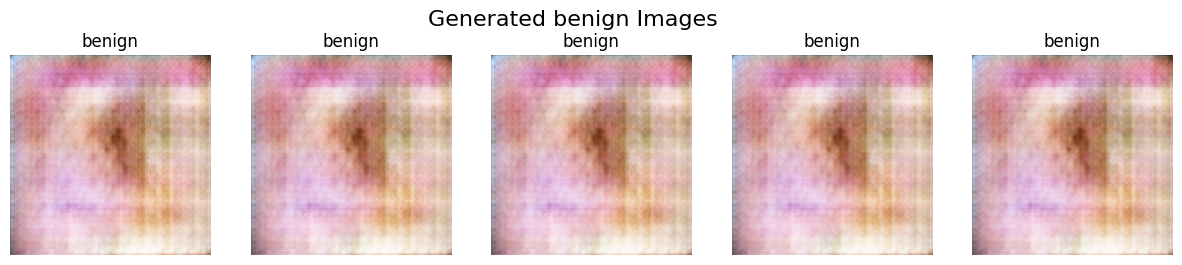

Min/Max pixel value for malignant (rescaled): 0.0000/0.9978
Saved generated samples to /content/drive/MyDrive/Colab_Notebooks/Data/cgan_artifacts/generated_samples/manual_malignant_grid.png


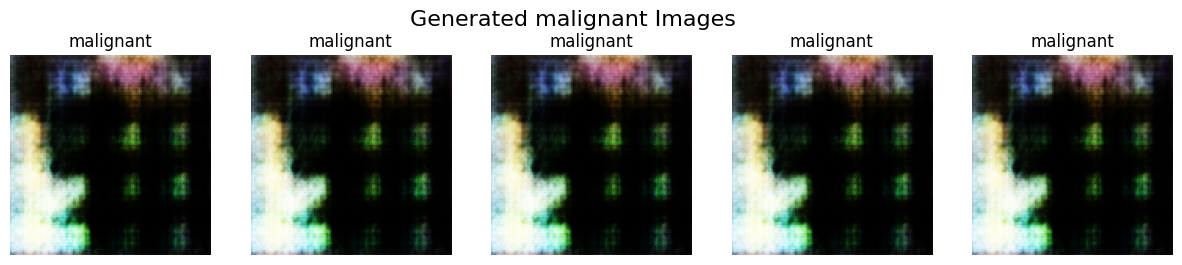

In [53]:
# Generate and display images for 'benign' class
generate_and_display_images(generator, NOISE_DIM, CLASS_TO_INDEX, 'benign', num_samples=5, output_path=SAMPLE_DIR / 'manual_benign_grid.png')

# Generate and display images for 'malignant' class
generate_and_display_images(generator, NOISE_DIM, CLASS_TO_INDEX, 'malignant', num_samples=5, output_path=SAMPLE_DIR / 'manual_malignant_grid.png')

### Training History After Retraining

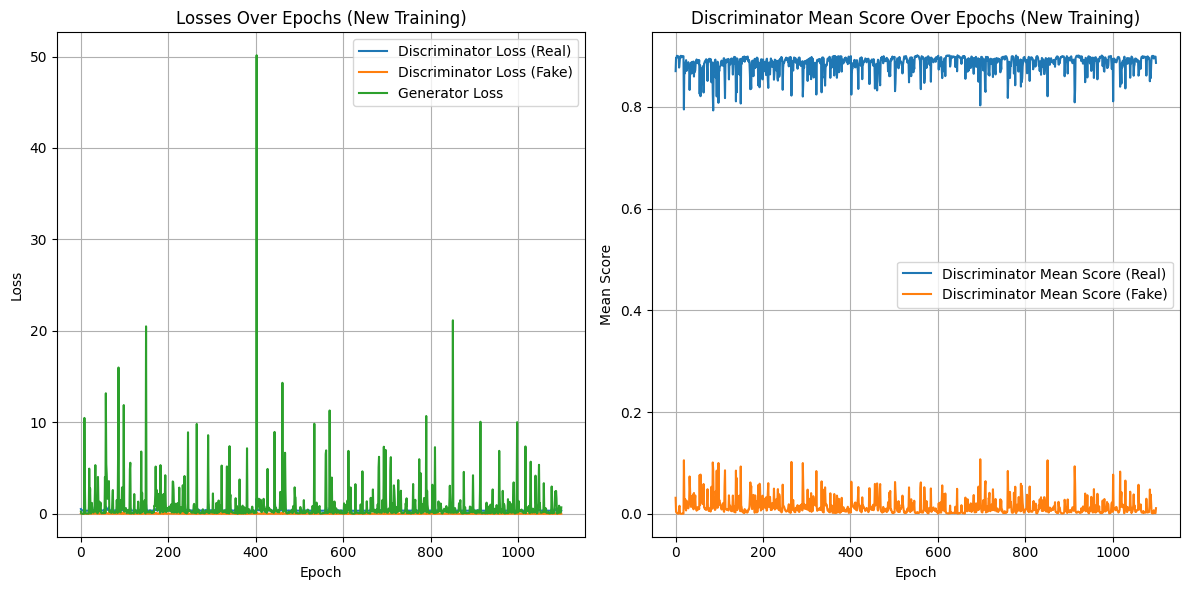

In [54]:
# Plotting training history
plt.figure(figsize=(12, 6))

# Plot Discriminator Loss
plt.subplot(1, 2, 1)
plt.plot(history['d_loss_real'], label='Discriminator Loss (Real)')
plt.plot(history['d_loss_fake'], label='Discriminator Loss (Fake)')
plt.plot(history['g_loss'], label='Generator Loss')
plt.title('Losses Over Epochs (New Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Discriminator Mean Score
plt.subplot(1, 2, 2)
plt.plot(history['d_real_score'], label='Discriminator Mean Score (Real)')
plt.plot(history['d_fake_score'], label='Discriminator Mean Score (Fake)')
plt.title('Discriminator Mean Score Over Epochs (New Training)')
plt.xlabel('Epoch')
plt.ylabel('Mean Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

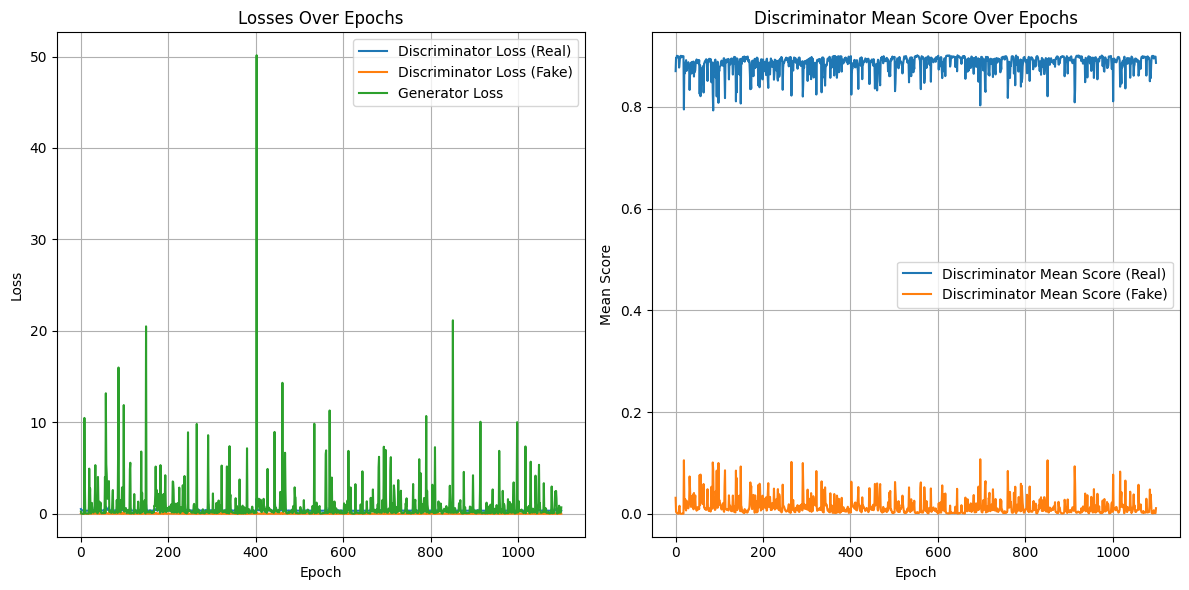

In [55]:
# Plotting training history
plt.figure(figsize=(12, 6))

# Plot Discriminator Loss
plt.subplot(1, 2, 1)
plt.plot(history['d_loss_real'], label='Discriminator Loss (Real)')
plt.plot(history['d_loss_fake'], label='Discriminator Loss (Fake)')
plt.plot(history['g_loss'], label='Generator Loss')
plt.title('Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Discriminator Mean Score
plt.subplot(1, 2, 2)
plt.plot(history['d_real_score'], label='Discriminator Mean Score (Real)')
plt.plot(history['d_fake_score'], label='Discriminator Mean Score (Fake)')
plt.title('Discriminator Mean Score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

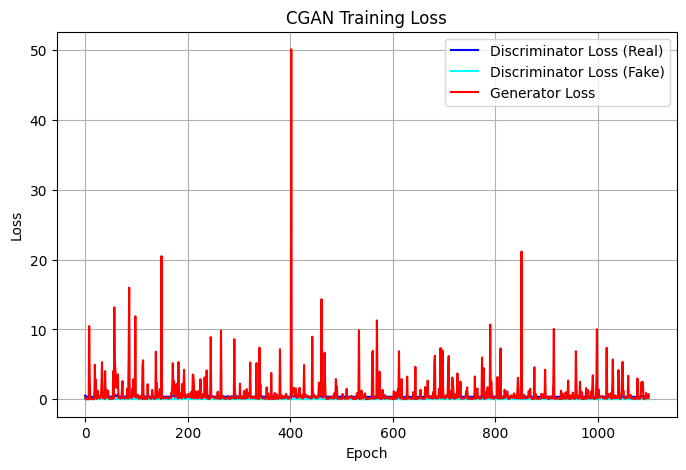

In [56]:
# Plot losses
plt.figure(figsize=(8,5))
plt.plot(history['d_loss_real'], label='Discriminator Loss (Real)', color='blue')
plt.plot(history['d_loss_fake'], label='Discriminator Loss (Fake)', color='cyan')
plt.plot(history['g_loss'], label='Generator Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CGAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()